# Laboratorio - Técnicas de Agrupación de Datos
## K-Means, DBSCAN y GMM sobre Fashion-MNIST

In [6]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score

np.random.seed(0)
plt.rcParams["figure.figsize"] = (7, 5)


## 0.1 Cargar Fashion-MNIST

In [7]:

# --- usando sklearn.fetch_openml  ---
from sklearn.datasets import fetch_openml
fashion = fetch_openml('Fashion-MNIST', version=1, as_frame=False)
X_full = fashion.data.astype('float32') / 255.0
y_full = fashion.target.astype(int)
x_train, y_train = X_full[:60000], y_full[:60000]
n_classes = len(np.unique(y_train))


In [8]:

"""
Fashion-MNIST tiene 60.000 imágenes, para que el analis sea en un tiempo razonable se usara una submuestra
Ajusta N_SAMPLES según tu capacidad de cómputo.
"""
N_SAMPLES = 10000
idx = np.random.choice(x_train.shape[0], N_SAMPLES, replace=False)
X = x_train[idx]
y = y_train[idx]
print("Subset:", X.shape)


Subset: (10000, 784)


# 4.1 K-Means Clustering

### Benchmarking: inicialización aleatoria vs. K-Means++ vs. inicialización con PCA

- `n_init=4` para las inicializaciones estocásticas (random, k-means++), ya que K-Means
  es un método estocástico y conviene repetir varias corridas.
- `n_init=1` cuando se inicializa con PCA (determinista).


In [9]:

import time

results = {}

# 1) K-Means con inicialización aleatoria
t0 = time.time()
kmeans_random = KMeans(init="random", n_clusters=n_classes, n_init=4, random_state=0)
kmeans_random.fit(X)
results["random"] = {
    "inertia": kmeans_random.inertia_,
    "time": time.time() - t0,
    "n_iter": kmeans_random.n_iter_,
}

# 2) K-Means con inicialización K-Means++
t0 = time.time()
kmeans_pp = KMeans(init="k-means++", n_clusters=n_classes, n_init=4, random_state=0)
kmeans_pp.fit(X)
results["k-means++"] = {
    "inertia": kmeans_pp.inertia_,
    "time": time.time() - t0,
    "n_iter": kmeans_pp.n_iter_,
}

# 3) K-Means con inicialización usando componentes principales (PCA)
t0 = time.time()
pca_init = PCA(n_components=n_classes, random_state=0).fit(X)
kmeans_pca_init = KMeans(init=pca_init.components_, n_clusters=n_classes, n_init=1, random_state=0)
kmeans_pca_init.fit(X)
results["pca-init"] = {
    "inertia": kmeans_pca_init.inertia_,
    "time": time.time() - t0,
    "n_iter": kmeans_pca_init.n_iter_,
}

import pandas as pd
df_results = pd.DataFrame(results).T
print(df_results)


                inertia      time  n_iter
random     318473.96875  0.641225    85.0
k-means++  318474.31250  1.474438    63.0
pca-init   320120.43750  0.435896    44.0


- pca-init es el mas rápido y con menos iteraciones
- k-means++ tardó más que random a pesar de tener menos iteraciones
- random necesitó más iteraciones (85) para converger

### K-Means + PCA para visualización

Reducimos a 2 componentes principales para poder graficar los clusters y los centroides en 2D.


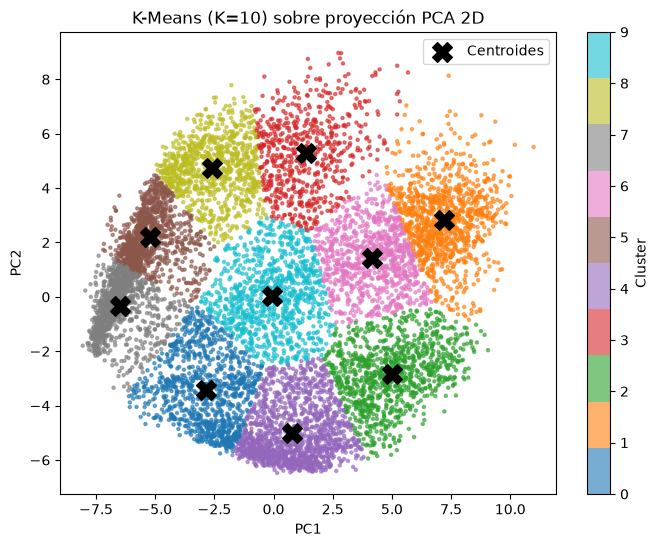

In [10]:

pca_2d = PCA(n_components=2, random_state=0)
X_pca_2d = pca_2d.fit_transform(X)

kmeans_2d = KMeans(init="k-means++", n_clusters=n_classes, n_init=4, random_state=0)
labels_2d = kmeans_2d.fit_predict(X_pca_2d)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_2d, cmap="tab10", s=5, alpha=0.6)
centroids = kmeans_2d.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=200, label="Centroides")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means (K=10) sobre proyección PCA 2D")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()


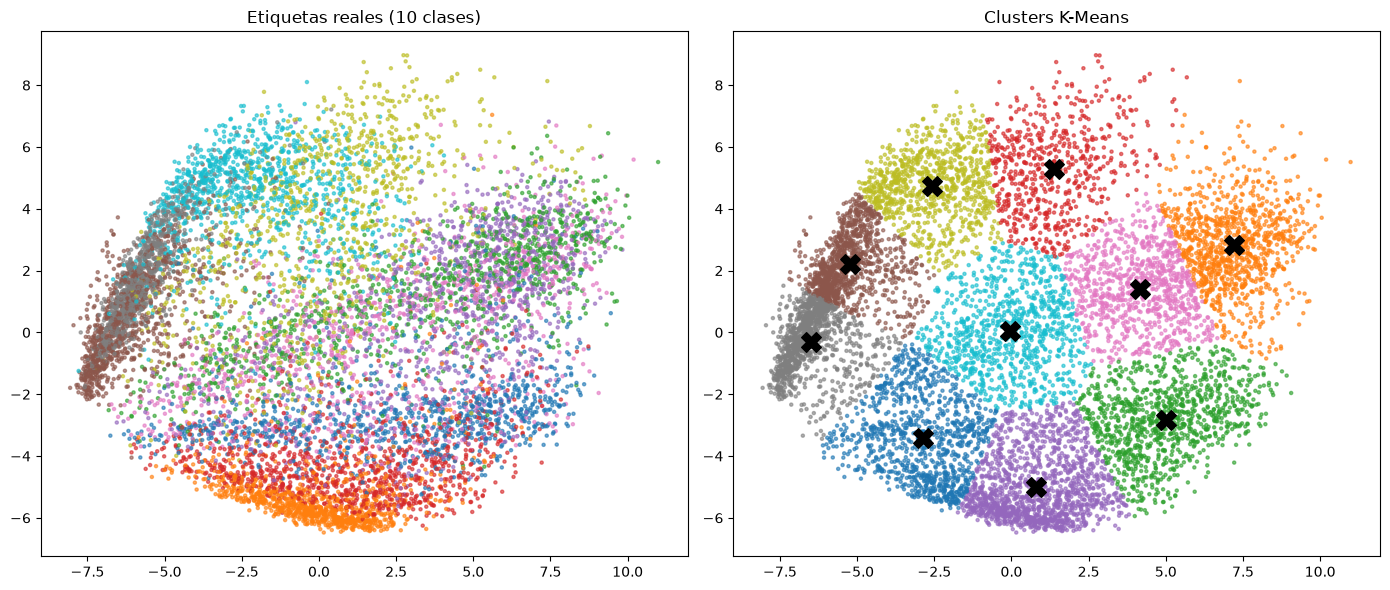

In [11]:

# Comparación visual: colorear por etiqueta REAL vs. por cluster asignado
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap="tab10", s=5, alpha=0.6)
axes[0].set_title("Etiquetas reales (10 clases)")

axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_2d, cmap="tab10", s=5, alpha=0.6)
axes[1].scatter(centroids[:, 0], centroids[:, 1], c="black", marker="X", s=200)
axes[1].set_title("Clusters K-Means")

plt.tight_layout()
plt.show()


### SSE (inercia) vs. número de clusters K

 Método del codo

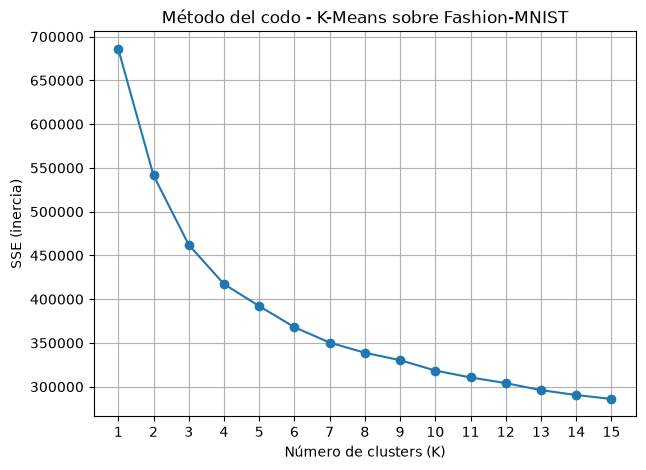

In [12]:

k_range = range(1, 16)
sse = []

for k in k_range:
    km = KMeans(init="random", n_clusters=k, n_init=4, random_state=0)
    km.fit(X)
    sse.append(km.inertia_)

plt.figure()
plt.plot(list(k_range), sse, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("SSE (inercia)")
plt.title("Método del codo - K-Means sobre Fashion-MNIST")
plt.xticks(list(k_range))
plt.grid(True)
plt.show()


**Discusión:**
Mirando el gráfico, el codo se nota más entre K=4 y K=5, no en K=10. Tiene sentido que no
coincidan: K-Means asume que los clusters son más o menos esféricos y del mismo tamaño, pero
varias prendas de Fashion-MNIST se parecen mucho entre sí en términos de pixeles (una camiseta,
una camisa, un abrigo y un pullover tienen siluetas parecidas), así que sus "nubes" de puntos
terminan solapándose en vez de formar 10 grupos bien separados. La inercia baja fuerte al
principio porque el modelo separa primero lo obvio (zapatos vs. ropa vs. bolsos), y después de
eso cada cluster nuevo solo divide un poco más fino sin un cambio brusco.


# 4.2 DBSCAN

### Paso 1: PCA + DBSCAN base

In [13]:

pca_30 = PCA(n_components=30, random_state=0)
X_train_pca = pca_30.fit_transform(X)

dbscan = DBSCAN(eps=3.0, min_samples=10)
labels_db = dbscan.fit_predict(X_train_pca)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_pct = np.mean(labels_db == -1) * 100

print(f"Clusters encontrados: {n_clusters_db}")
print(f"Porcentaje de ruido: {noise_pct:.2f}%")


Clusters encontrados: 2
Porcentaje de ruido: 14.86%


### Paso 2: Benchmarking variando `eps` (con `min_samples` fijo)

    eps  n_clusters  noise_pct
0   0.5           0     100.00
1   1.0           1      99.76
2   1.5          11      89.91
3   2.0          15      66.22
4   2.5          10      34.83
5   3.0           2      14.86
6   4.0           1       2.10
7   5.0           1       0.33
8   7.0           1       0.00
9  10.0           1       0.00


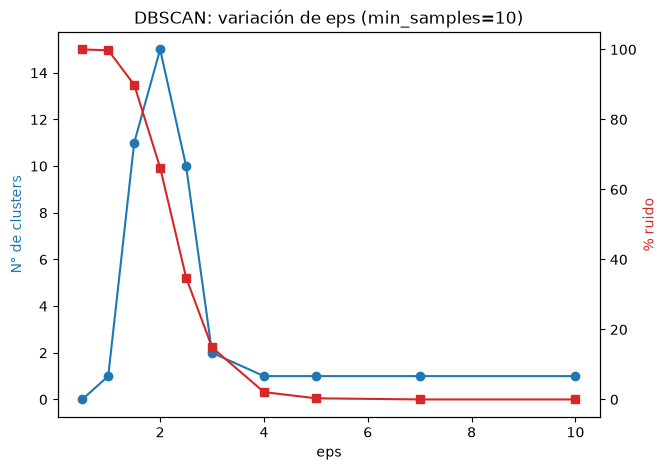

In [14]:

eps_values = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 7.0, 10.0]
min_samples_fixed = 10

eps_results = []
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples_fixed)
    labels_tmp = db.fit_predict(X_train_pca)
    n_clust = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    noise = np.mean(labels_tmp == -1) * 100
    eps_results.append({"eps": eps, "n_clusters": n_clust, "noise_pct": noise})

df_eps = pd.DataFrame(eps_results)
print(df_eps)

fig, ax1 = plt.subplots()
ax1.plot(df_eps["eps"], df_eps["n_clusters"], marker="o", color="tab:blue", label="N° clusters")
ax1.set_xlabel("eps")
ax1.set_ylabel("N° de clusters", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(df_eps["eps"], df_eps["noise_pct"], marker="s", color="tab:red", label="% ruido")
ax2.set_ylabel("% ruido", color="tab:red")
plt.title(f"DBSCAN: variación de eps (min_samples={min_samples_fixed})")
plt.show()


### Paso 2 (cont.): Benchmarking variando `min_samples` (con `eps` fijo)

   min_samples  n_clusters  noise_pct
0            2          69       8.32
1            5           7      11.17
2           10           2      14.86
3           15           4      18.16
4           20           3      20.45
5           30           4      26.07
6           50           2      37.93


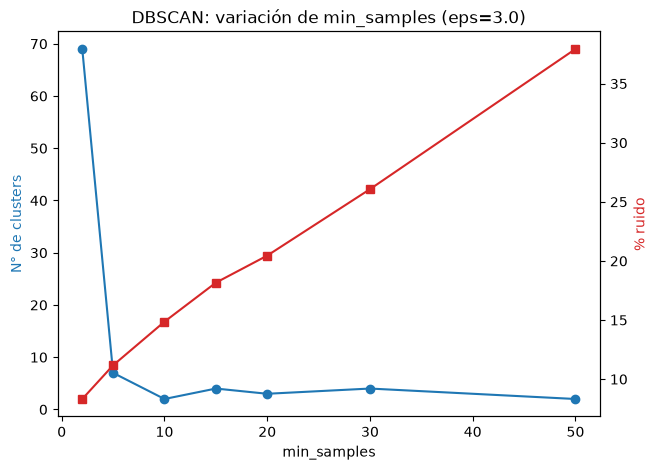

In [15]:

eps_fixed = 3.0  # ajusta según lo observado en el paso anterior
min_samples_values = [2, 5, 10, 15, 20, 30, 50]

ms_results = []
for ms in min_samples_values:
    db = DBSCAN(eps=eps_fixed, min_samples=ms)
    labels_tmp = db.fit_predict(X_train_pca)
    n_clust = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    noise = np.mean(labels_tmp == -1) * 100
    ms_results.append({"min_samples": ms, "n_clusters": n_clust, "noise_pct": noise})

df_ms = pd.DataFrame(ms_results)
print(df_ms)

fig, ax1 = plt.subplots()
ax1.plot(df_ms["min_samples"], df_ms["n_clusters"], marker="o", color="tab:blue", label="N° clusters")
ax1.set_xlabel("min_samples")
ax1.set_ylabel("N° de clusters", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(df_ms["min_samples"], df_ms["noise_pct"], marker="s", color="tab:red", label="% ruido")
ax2.set_ylabel("% ruido", color="tab:red")
plt.title(f"DBSCAN: variación de min_samples (eps={eps_fixed})")
plt.show()


**Discusión:**
Con eps muy chico, casi todo termina marcado como ruido porque ningún punto logra juntar
suficientes vecinos tan cerca. Si el eps es muy grande pasa lo contrario: se une todo en un solo
cluster gigante, porque el radio es tan amplio que prácticamente conecta todo el dataset. Con
min_samples muy bajo aparecen un montón de clusters chiquitos que en realidad son ruido
disfrazado de grupo. Y si min_samples es muy alto, cuesta mucho más que un punto se considere
"núcleo", así que el porcentaje de ruido sube.


### Paso 3: Benchmarking variando la métrica de distancia

In [16]:

metrics_to_test = ["euclidean", "manhattan", "cosine"]
eps_by_metric = {"euclidean": 3.0, "manhattan": 10.0, "cosine": 0.05}  # ajustar según cada métrica
min_samples_fixed2 = 10

metric_results = []
for metric in metrics_to_test:
    db = DBSCAN(eps=eps_by_metric[metric], min_samples=min_samples_fixed2, metric=metric)
    labels_tmp = db.fit_predict(X_train_pca)
    n_clust = len(set(labels_tmp)) - (1 if -1 in labels_tmp else 0)
    noise = np.mean(labels_tmp == -1) * 100
    metric_results.append({"metric": metric, "eps": eps_by_metric[metric],
                            "n_clusters": n_clust, "noise_pct": noise})

df_metric = pd.DataFrame(metric_results)
print(df_metric)


      metric    eps  n_clusters  noise_pct
0  euclidean   3.00           2      14.86
1  manhattan  10.00          14      43.69
2     cosine   0.05           7      39.35


**Nota:** al cambiar de métrica, `eps` debe reajustarse porque se interpreta en las unidades
de esa métrica (p. ej. `cosine` va de 0 a 2, mientras que `euclidean`/`manhattan` dependen de la
escala de los datos). Ajusta `eps_by_metric` explorando distintos valores hasta obtener un número
de clusters razonable con poco ruido.

### Paso 4: Heurística del k-ésimo vecino más cercano para elegir `eps`

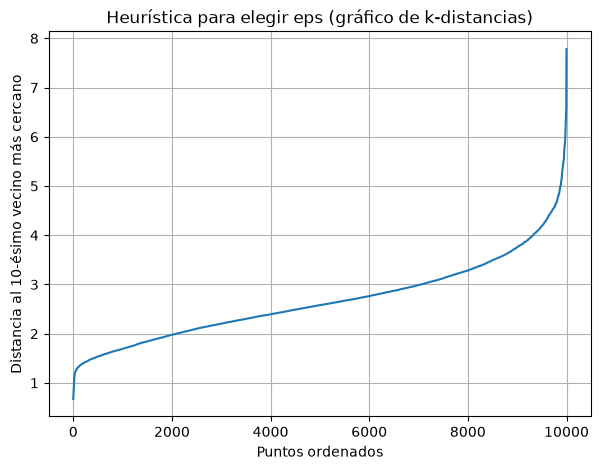

In [17]:

k = 10  # equivalente a min_samples
neighbors = NearestNeighbors(n_neighbors=k).fit(X_train_pca)
distances, _ = neighbors.kneighbors(X_train_pca)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.ylabel(f"Distancia al {k}-ésimo vecino más cercano")
plt.xlabel("Puntos ordenados")
plt.title("Heurística para elegir eps (gráfico de k-distancias)")
plt.grid(True)
plt.show()

# El "codo" de esta curva sugiere un valor razonable de eps.


### Paso 5: Visualización 2D de los clusters DBSCAN (incluyendo ruido)

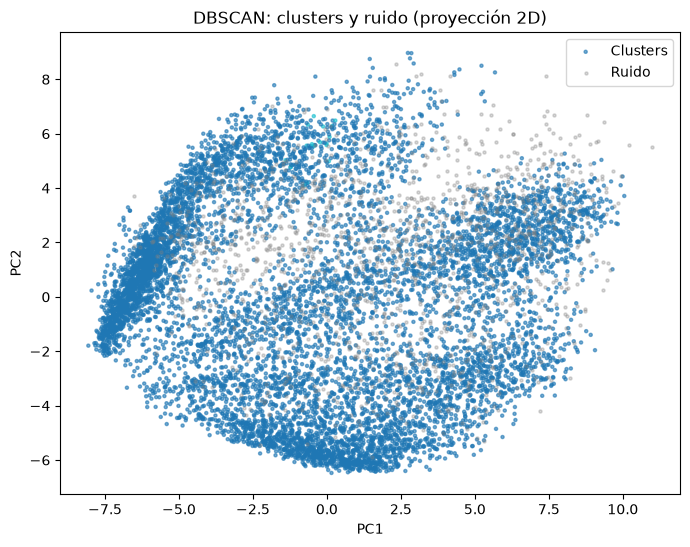

In [18]:

# Reutilizamos PCA a 2D para visualizar (también podrías usar t-SNE/UMAP,
# fundamentando la elección: t-SNE/UMAP suelen separar mejor grupos no lineales,
# pero PCA es más rápido y determinista).
X_pca_2d_db = pca_2d.transform(X)  # usa el mismo pca_2d entrenado antes, o entrena uno nuevo

eps_final = 3.0
min_samples_final = 10
dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final)
labels_db_final = dbscan_final.fit_predict(X_train_pca)

plt.figure(figsize=(8, 6))
noise_mask = labels_db_final == -1

plt.scatter(X_pca_2d_db[~noise_mask, 0], X_pca_2d_db[~noise_mask, 1],
            c=labels_db_final[~noise_mask], cmap="tab10", s=5, alpha=0.6, label="Clusters")
plt.scatter(X_pca_2d_db[noise_mask, 0], X_pca_2d_db[noise_mask, 1],
            c="gray", s=5, alpha=0.3, label="Ruido")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN: clusters y ruido (proyección 2D)")
plt.legend()
plt.show()


**Discusión:**
DBSCAN lo hace bastante peor que K-Means para este dataset. Con los parámetros que probé, solo
salen uno o dos clusters de verdad y un montón de ruido repartido por toda la nube, sin que se
vean fronteras claras. K-Means en cambio sí logra separar regiones más definidas. Esto pasa
porque en el espacio reducido con PCA los datos de Fashion-MNIST no tienen esos "espacios
vacíos" entre clases que DBSCAN necesita para distinguir densidades — las clases están pegadas
unas con otras, que es justo el peor escenario para un método basado en densidad.


# 4.3 Gaussian Mixture Models (GMM)

### Paso 1: Ajustar GMM con K=10 componentes sobre PCA

In [19]:

gmm = GaussianMixture(n_components=10, covariance_type="full", random_state=0)
gmm.fit(X_train_pca)

labels_gmm = gmm.predict(X_train_pca)          # asignación dura
probs_gmm = gmm.predict_proba(X_train_pca)      # asignación suave

# Comparar tamaño de clusters GMM vs K-Means
unique_gmm, counts_gmm = np.unique(labels_gmm, return_counts=True)
unique_km, counts_km = np.unique(kmeans_pp.labels_, return_counts=True)

print("Tamaño de clusters GMM:", dict(zip(unique_gmm, counts_gmm)))
print("Tamaño de clusters K-Means:", dict(zip(unique_km, counts_km)))


Tamaño de clusters GMM: {np.int64(0): np.int64(1587), np.int64(1): np.int64(1216), np.int64(2): np.int64(415), np.int64(3): np.int64(1209), np.int64(4): np.int64(1085), np.int64(5): np.int64(789), np.int64(6): np.int64(947), np.int64(7): np.int64(838), np.int64(8): np.int64(1460), np.int64(9): np.int64(454)}
Tamaño de clusters K-Means: {np.int32(0): np.int64(1249), np.int32(1): np.int64(1103), np.int32(2): np.int64(1188), np.int32(3): np.int64(1262), np.int32(4): np.int64(1538), np.int32(5): np.int64(388), np.int32(6): np.int64(408), np.int32(7): np.int64(1684), np.int32(8): np.int64(459), np.int32(9): np.int64(721)}


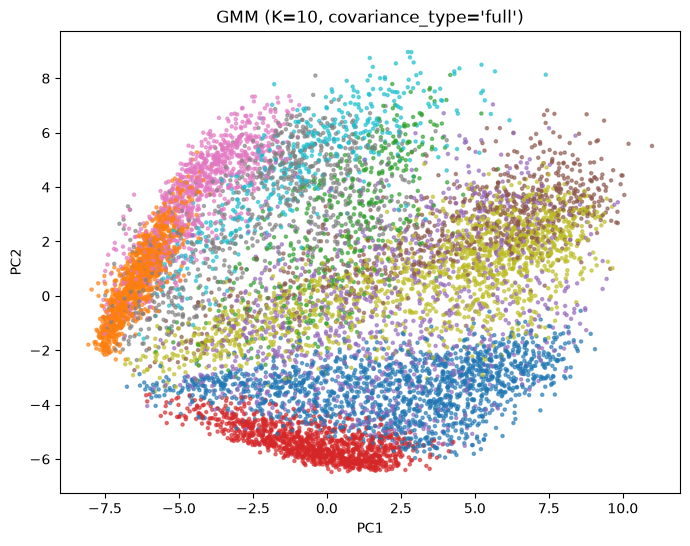

In [20]:

# Visualización 2D de los clusters de GMM
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d_db[:, 0], X_pca_2d_db[:, 1], c=labels_gmm, cmap="tab10", s=5, alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("GMM (K=10, covariance_type='full')")
plt.show()


### Paso 2: Benchmarking de `covariance_type`

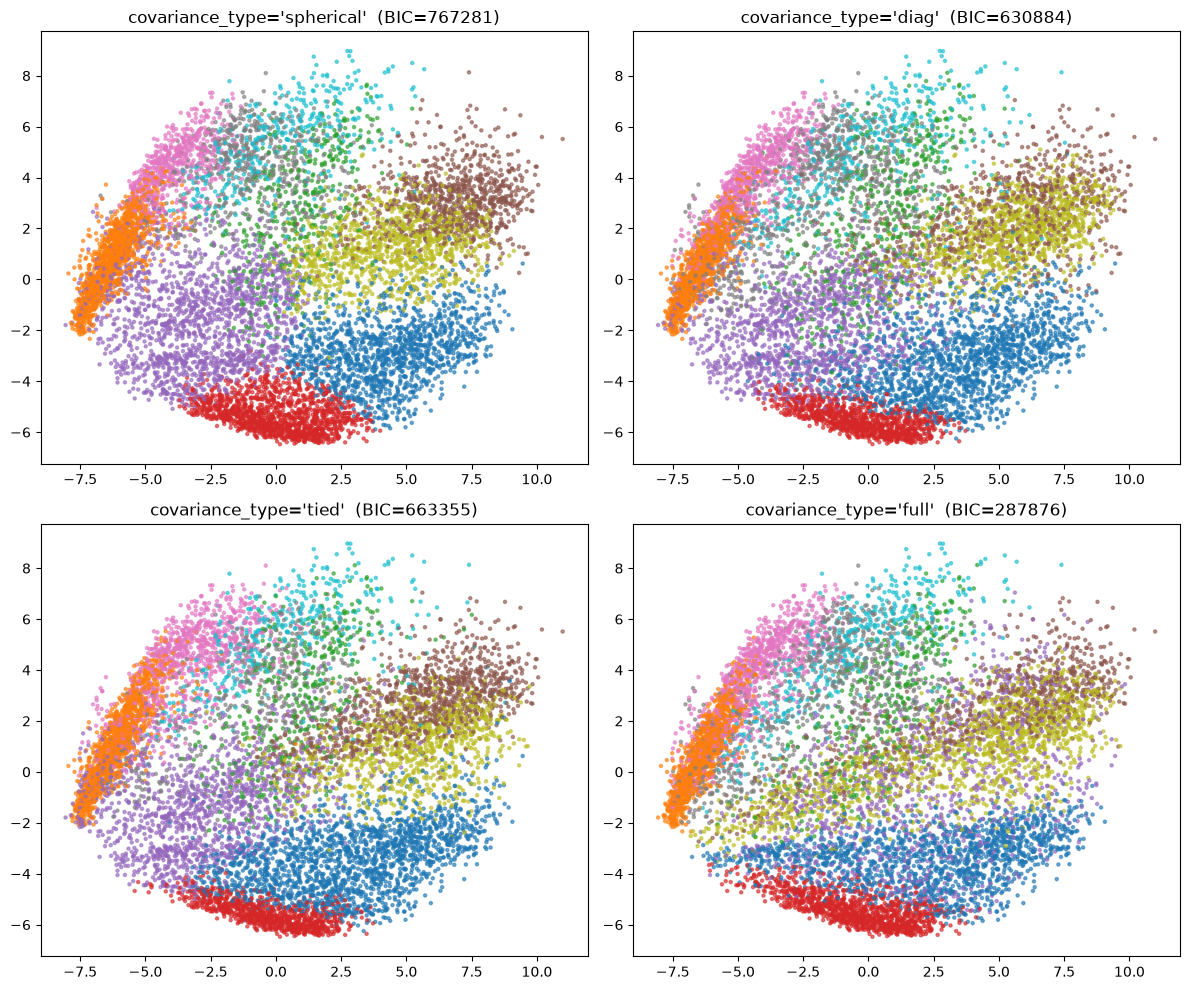

In [21]:

cov_types = ["spherical", "diag", "tied", "full"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, cov_type in zip(axes.ravel(), cov_types):
    gmm_tmp = GaussianMixture(n_components=10, covariance_type=cov_type, random_state=0)
    labels_tmp = gmm_tmp.fit_predict(X_train_pca)
    ax.scatter(X_pca_2d_db[:, 0], X_pca_2d_db[:, 1], c=labels_tmp, cmap="tab10", s=5, alpha=0.6)
    ax.set_title(f"covariance_type='{cov_type}'  (BIC={gmm_tmp.bic(X_train_pca):.0f})")

plt.tight_layout()
plt.show()


**Nota:** `covariance_type='spherical'` es conceptualmente el más parecido al supuesto
implícito de K-Means (clusters esféricos). A medida que se permite más flexibilidad
(`diag` → `tied` → `full`), los clusters pueden adoptar formas elípticas más generales,
a costa de más parámetros a estimar.

### Paso 3: BIC / AIC en función de K

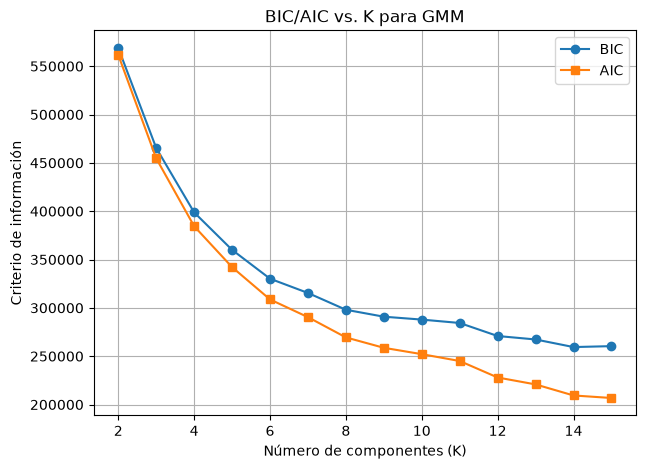

In [22]:

k_range_gmm = range(2, 16)
bic_scores, aic_scores = [], []

for k in k_range_gmm:
    gmm_k = GaussianMixture(n_components=k, covariance_type="full", random_state=0, max_iter=200)
    gmm_k.fit(X_train_pca)
    bic_scores.append(gmm_k.bic(X_train_pca))
    aic_scores.append(gmm_k.aic(X_train_pca))

plt.figure()
plt.plot(list(k_range_gmm), bic_scores, marker="o", label="BIC")
plt.plot(list(k_range_gmm), aic_scores, marker="s", label="AIC")
plt.xlabel("Número de componentes (K)")
plt.ylabel("Criterio de información")
plt.title("BIC/AIC vs. K para GMM")
plt.legend()
plt.grid(True)
plt.show()


**Discusión:**
BIC y AIC le meten una penalización por complejidad porque si no, el modelo siempre va a
preferir más componentes: la verosimilitud nunca empeora agregando más clusters, así que sin
penalización terminaríamos eligiendo un K gigante, básicamente sobreajustando (casi un cluster
por punto). La curva de BIC se parece bastante a la del SSE de K-Means: cae fuerte al principio
y después se aplana. En mi caso, BIC sugiere que un K más cercano a 13-14 ajusta mejor que K=10.


### Paso 4: Inspección de probabilidades de pertenencia (asignación suave)

In [23]:

# Elegimos un subconjunto pequeño de observaciones para inspeccionar
sample_idx = np.random.choice(len(X), 20, replace=False)
sample_probs = probs_gmm[sample_idx]

max_prob = sample_probs.max(axis=1)
dominant_idx = sample_idx[np.argmax(max_prob)]           # probabilidad muy dominante
ambiguous_idx = sample_idx[np.argmin(max_prob)]           # probabilidades más repartidas

print("Observación con asignación dominante:")
print(np.round(probs_gmm[dominant_idx], 3))

print("\nObservación con asignación ambigua:")
print(np.round(probs_gmm[ambiguous_idx], 3))


Observación con asignación dominante:
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]

Observación con asignación ambigua:
[0.   0.   0.   0.   0.   0.21 0.   0.   0.79 0.  ]


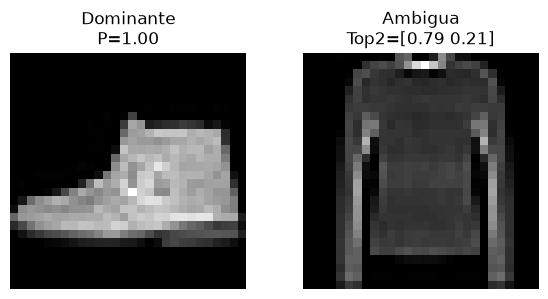

In [24]:

# Mostrar las imágenes originales correspondientes
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(X[dominant_idx].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Dominante\nP={probs_gmm[dominant_idx].max():.2f}")
axes[0].axis("off")

axes[1].imshow(X[ambiguous_idx].reshape(28, 28), cmap="gray")
top2 = np.sort(probs_gmm[ambiguous_idx])[::-1][:2]
axes[1].set_title(f"Ambigua\nTop2={top2.round(2)}")
axes[1].axis("off")

plt.tight_layout()
plt.show()


**Discusión:**
Lo interesante de GMM es que te dice qué tan "segura" está la asignación. En el ejemplo
dominante, el modelo le puso 100% de probabilidad a un solo cluster, sin dudar. En el otro caso,
la probabilidad quedó repartida 79%/21% entre dos clusters, lo que sugiere que esa prenda
comparte características visuales con dos categorías distintas. Eso es algo que ni K-Means ni
DBSCAN pueden mostrar, porque ambos asignan cada punto a un único cluster sin matices. Esta
info sirve para detectar casos límite que capaz convendría revisar a mano, o para sistemas que
necesitan expresar cierta incertidumbre en vez de una respuesta tajante.
